<a href="https://colab.research.google.com/github/souravk03/Machine-Learning-404/blob/main/Day_32_Binning_Descritization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Discretization
it is the process of transforming continous variable into discrete variable by creating a set of contiguous intervals that span the rnage of variable values. Discretization is also calledbinning where bins are the intervals.

####Why we use binning?
1. To handle outliers
2. To improve the value spread

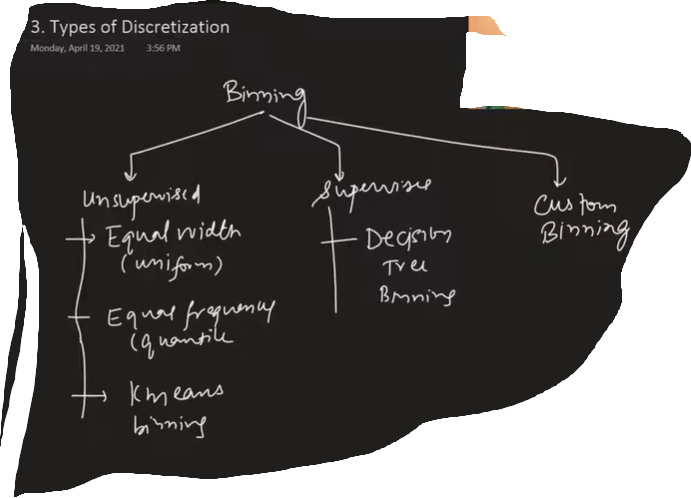

###Equal width/uniform binning
interval=(max-min)/bins

##Equal Frequency/Quatile binning
in the number of values in each interval is equal.

if interval is 10 each interval contain the  10 % of total obervation.

Adv
1. Outliers handing
2. uniform value spread

##Kmeans Binning

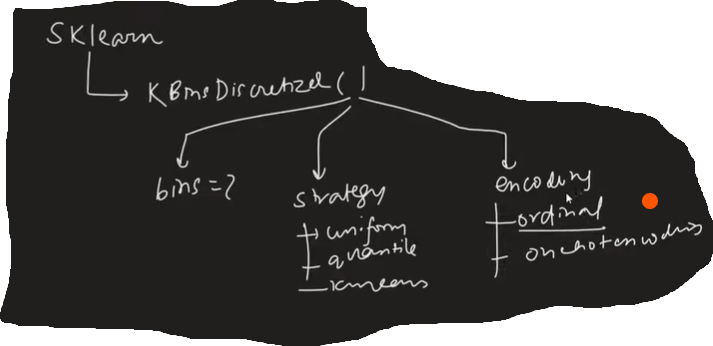

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score

In [3]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/train.csv',usecols=['Age','Fare','Survived'])

In [6]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [7]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [8]:
df.shape

(891, 3)

In [9]:
df.dropna(inplace=True)

In [10]:
df.shape

(714, 3)

In [11]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [17]:
X=df.iloc[:,1:]
y=df['Survived']


In [18]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=
                                           42)

In [26]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [23]:
clf=DecisionTreeClassifier()

In [27]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [28]:
accuracy_score(y_test,y_pred)

0.6223776223776224

In [30]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6288928012519561)

In [31]:
kbin_age=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [32]:

trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [33]:

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [34]:

trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [35]:

trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [36]:

output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [37]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [38]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
193,3.0,0.0,26.0000,9.0,"(0.42, 6.0]","(18.75, 26.0]"
472,33.0,9.0,27.7500,10.0,"(32.0, 35.0]","(26.55, 31.275]"
173,21.0,4.0,7.9250,3.0,"(19.0, 21.0]","(7.896, 8.158]"
493,71.0,14.0,49.5042,11.0,"(54.0, 80.0]","(31.275, 51.479]"
607,27.0,6.0,30.5000,10.0,"(25.0, 28.0]","(26.55, 31.275]"


In [39]:

clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [40]:

accuracy_score(y_test,y_pred2)

0.6363636363636364

In [41]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6247261345852895)

In [51]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()


0.6288928012519561


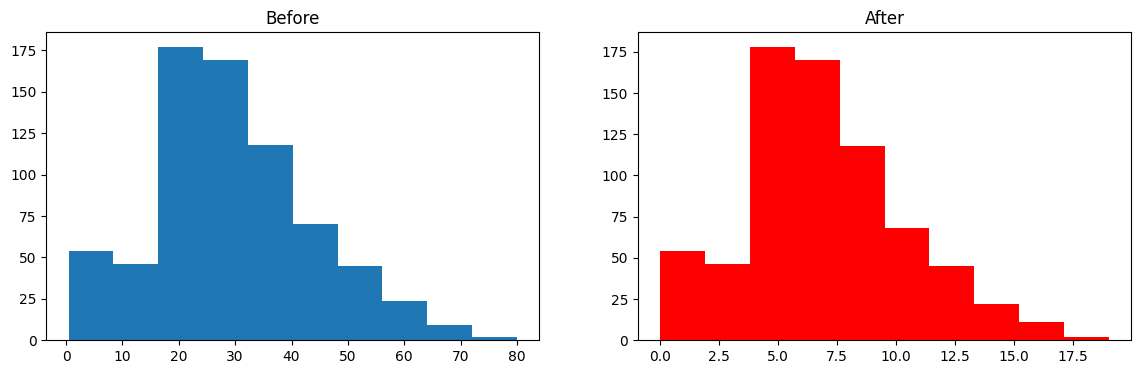

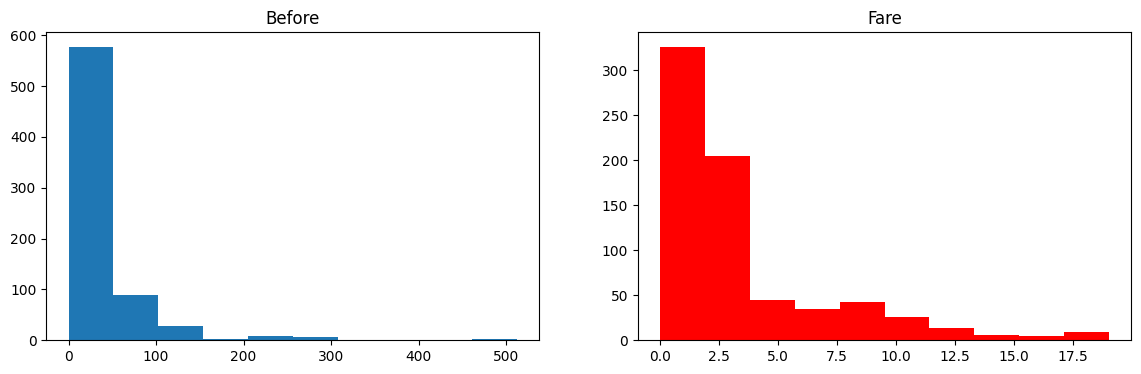

In [52]:
discretize(20,'kmeans')

0.6344874804381846


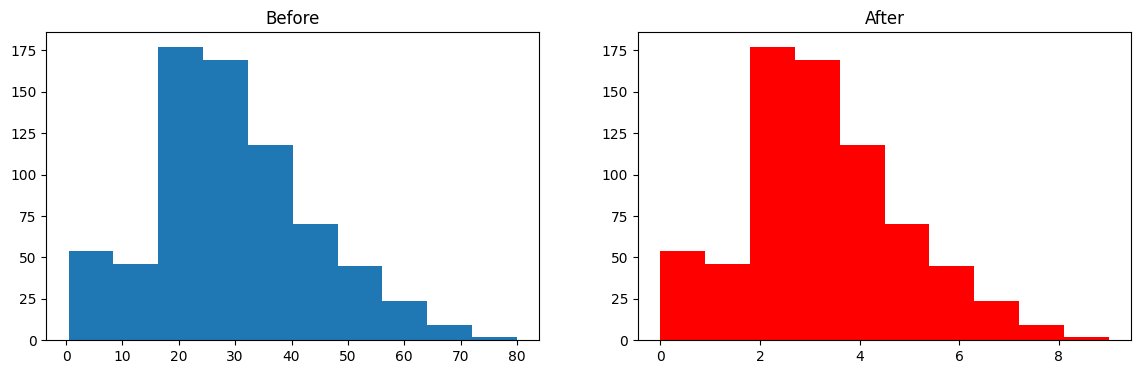

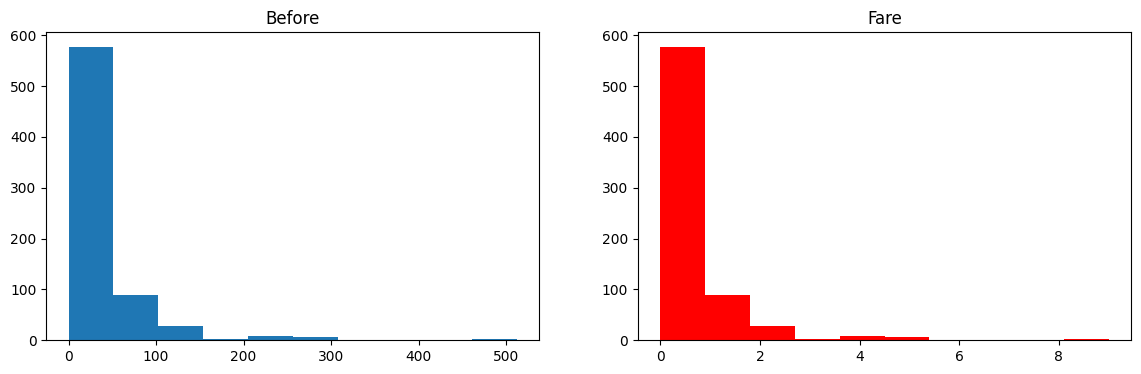

In [53]:
discretize(10,'uniform')

0.6331377151799686


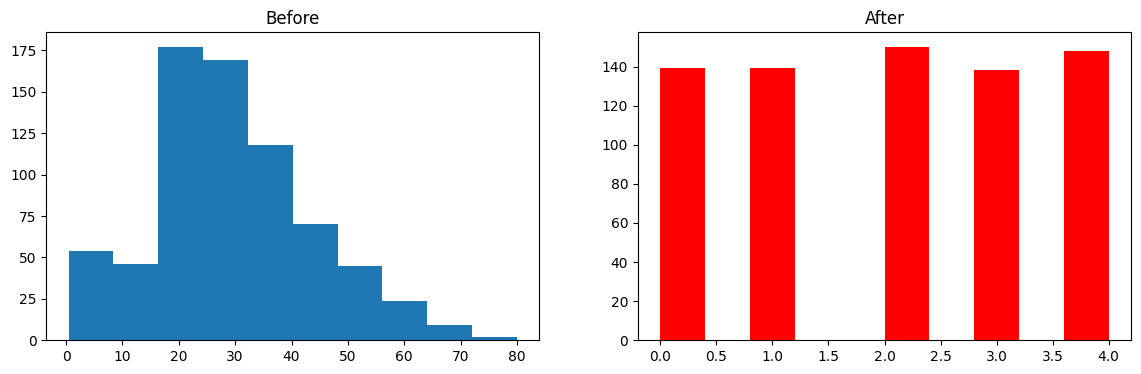

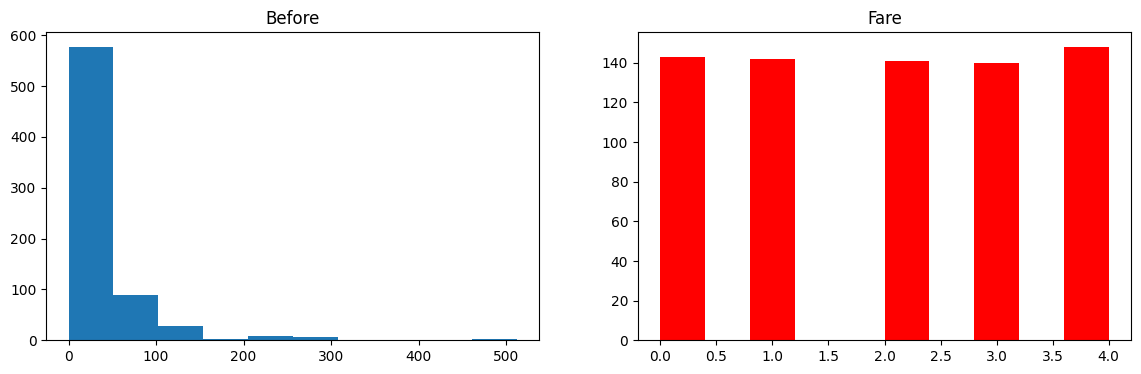

In [54]:
discretize(5,'quantile')